In [ ]:
!pip freeze

absl-py==1.4.0
accelerate==1.12.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.2
aiosignal==1.4.0
aiosqlite==0.22.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.17.2
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.0
anywidget==0.9.21
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2025.12.15.0.40.51
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.6
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.30.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.1.0
blosc2==3.12.2
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.4
catalogue==2.0.10
certifi==2025.11.12
cffi==2.0.0
chardet==5.2.0
cha

# Load and extract data files

# Import modules and define functions for common use

In [28]:
def remove_large_jumps(df, threshold, x_col="x", y_col="y"):
    df = df.copy()

    x = df[x_col].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)

    # 最後に採用された点（初期は1行目）
    last_valid_x = x[0]
    last_valid_y = y[0]

    for i in range(1, len(df)):
        if np.isnan(x[i]) or np.isnan(y[i]):
            continue

        dist = np.sqrt((x[i] - last_valid_x)**2 + (y[i] - last_valid_y)**2)

        if dist >= threshold:
            x[i] = np.nan
            y[i] = np.nan
        else:
            last_valid_x = x[i]
            last_valid_y = y[i]

    df[x_col] = x
    df[y_col] = y

    return df

In [29]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import japanize_matplotlib
from scipy.optimize import linear_sum_assignment
import matplotlib as mpl
import seaborn as sns
from tqdm import tqdm
mpl.rcParams['svg.fonttype'] = 'none'

In [30]:
# 横長データ(x1, y1, x2, y2, ... の形式)をmanualと同じフォーマットの整然データに変更する
def convert_wide_to_long(df):
  col_list = df.columns
  value_vars = [col for col in col_list if col.startswith("x") or col.startswith("y")]
  id_vars = [col for col in col_list if not col.startswith("x") and not col.startswith("y")]
  df_melt = df.melt(value_vars=value_vars, id_vars=id_vars)
  df_melt["x_or_y"] = df_melt["variable"].str[0]
  df_melt["id"] = df_melt["variable"].str[1:]
  df_melt.drop("variable", axis=1, inplace=True)
  index_names = [item for item in list(df_melt.columns) if item not in ["value", "x_or_y"]]
  df_pivot = df_melt.pivot(index=index_names, columns="x_or_y", values="value")
  df_pivot.reset_index(inplace=True)
  return df_pivot

In [31]:
data = {}
for isNoisy in ["with_noise", "without_noise"]:
  for tool in ["", "_IdTracker", "_TRex", "_UMAtracker", "_manual"]:
    for replicate in ["0", "1"]:
      filename = f"{isNoisy}_{replicate}{tool}.csv"
      print(filename)
      #filenameがなければ、メッセージを表示しNoneを入れる
      if not os.path.exists(filename):
        print(f"●{filename} does not exist")
        data[filename] = None
        continue
      df = pd.read_csv(filename)
      if tool not in ["_TRex", "_manual", ""]:
        df_long = convert_wide_to_long(df)
        if tool == "_UMAtracker":
          df_long = df_long.rename(columns={"position": "frame"})
        if tool == "_IdTracker":
          df_long["frame"] = (df_long["time"]*30).astype(int)
      else:
        df_long = df
      data[filename] = df_long

with_noise_0.csv
with_noise_1.csv
with_noise_0_IdTracker.csv
with_noise_1_IdTracker.csv
with_noise_0_TRex.csv
with_noise_1_TRex.csv
with_noise_0_UMAtracker.csv
with_noise_1_UMAtracker.csv
with_noise_0_manual.csv
with_noise_1_manual.csv
without_noise_0.csv
without_noise_1.csv
without_noise_0_IdTracker.csv
without_noise_1_IdTracker.csv
without_noise_0_TRex.csv
without_noise_1_TRex.csv
without_noise_0_UMAtracker.csv
without_noise_1_UMAtracker.csv
without_noise_0_manual.csv
without_noise_1_manual.csv


In [53]:
fig, axes = plt.subplots(5, 4, figsize=(20, 30))
axes = axes.flatten()
for i, (filename, df) in enumerate(data.items()):
  ax = axes[i]
  ax.set_aspect("equal")
  ax.set_title(filename)
  if df is None:
    continue
  for id, df_ind in df.groupby("id"):
    #df_ind = df_ind.sort_values("frame", ascending=True)
    ax.plot(df_ind.x, df_ind.y)
  #ax.legend()
fig.tight_layout()
fig.show()

Output hidden; open in https://colab.research.google.com to view.

# Calculate distance from the nearest ground truth point

In [54]:
for isNoisy in ["with_noise", "without_noise"]:
  for replicate in ["0", "1"]:
    df_ground_truth = data[f"{isNoisy}_{replicate}.csv"]
    for tool in ["_IdTracker", "_TRex", "_UMAtracker", "_manual"]:
      print(f"{isNoisy}_{replicate}{tool}")
      df = data[f"{isNoisy}_{replicate}{tool}.csv"]
      if df is None:
        continue
      df = df.sort_values(["id", "frame"])
      df_ground_truth = df_ground_truth.sort_values(["id", "frame"])
      for idx, row in tqdm(df.iterrows(), total=len(df)):
        x = row.x
        y = row.y
        df_ground_truth_candidate = df_ground_truth[(df_ground_truth.frame == row.frame)].copy()
        df_ground_truth_candidate["deviation"] = np.sqrt((df_ground_truth_candidate.x - x)**2 + (df_ground_truth_candidate.y - y)**2)
        df.loc[idx, "deviation"] = df_ground_truth_candidate.deviation.min()
      data[f"{isNoisy}_{replicate}{tool}.csv"] = df

with_noise_0_IdTracker


100%|██████████| 21600/21600 [00:42<00:00, 504.07it/s]


with_noise_0_TRex


100%|██████████| 21315/21315 [00:35<00:00, 592.62it/s]


with_noise_0_UMAtracker


...

100%|██████████| 21564/21564 [00:37<00:00, 573.44it/s]


without_noise_1_UMAtracker


100%|██████████| 21600/21600 [00:37<00:00, 570.21it/s]


without_noise_1_manual


100%|██████████| 21612/21612 [00:37<00:00, 569.35it/s]


In [68]:
# 図のtick labelsのフォントサイズを16 ptに
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16

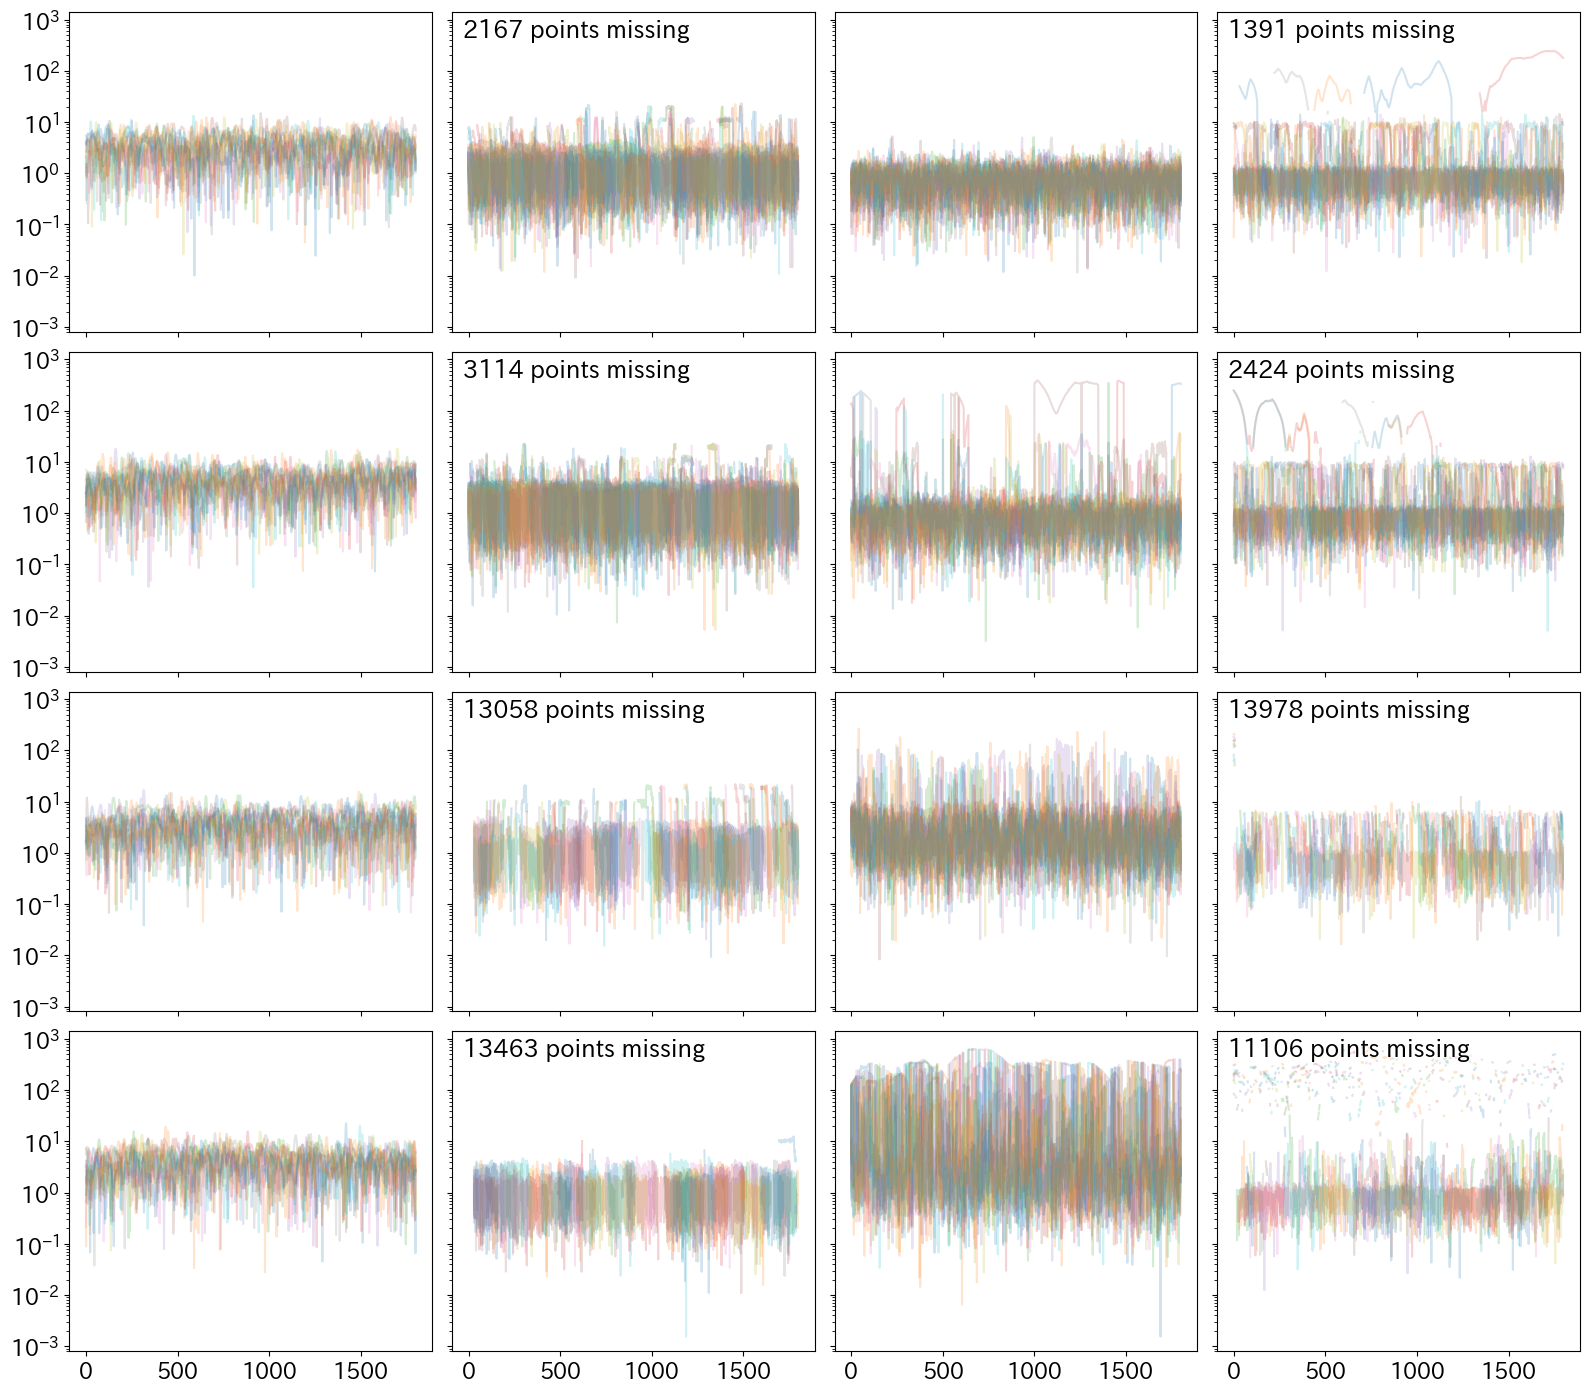

In [72]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14), sharey=True, sharex=True)
axes = axes.flatten()

counter = 0
for isNoisy in ["without_noise", "with_noise"]:
  for replicate in ["0", "1"]:
    df_ground_truth = data[f"{isNoisy}_{replicate}.csv"]
    for tool in ["_manual", "_IdTracker", "_UMAtracker", "_TRex"]:
      ax = axes[counter]
      #ax.set_aspect("equal")
      #ax.set_title(f"{isNoisy}_{replicate}{tool}")
      df = data[f"{isNoisy}_{replicate}{tool}.csv"]
      count_na = df.x.isna().sum()
      if count_na > 0:
        #print(f"Number of missing points: {count_na}")
        ax.text(0.03, 0.98, f"{count_na} points missing", horizontalalignment='left', verticalalignment='top', transform=ax.transAxes, size="xx-large")
      if df is None:
        continue
      for id, df_ind in df.groupby("id"):
        #df_ind = df_ind.sort_values("frame", ascending=True)
        ax.plot(df_ind.frame, df_ind.deviation, alpha=0.2)
        ax.set_yscale("log")
      #ax.legend()
      counter = counter + 1
fig.tight_layout()
fig.show()

In [73]:
fig.savefig("deviation.svg")